# Outlier Analysis Visualization
Load `outlier_results.h5` produced by notebook 3 and plot grid-point statistics
as a function of `amp_prefactor` and `charge_gate`.

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5

## 1. Configuration

In [2]:

output_folder = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP"

SHAPE_FOLDERS = {
    # "square":     r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\square",
    "square_AR":     r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\square_AR",
    # "square_AR_test":     r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\square_AR_test",

    # "two_step":   r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\two_step",
    "two_step_AR": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\two_step_AR",

    # "three_step_AR_n100": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\three_step_AR_n100",
    # "three_step_n100": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\three_step_n100",
    "three_step_AR": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\three_step_AR",
}

# output_folder = r"d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04"
# SHAPE_FOLDERS = {
#     # "square":     r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\square",
#     "square_AR":     os.path.join(output_folder, "square_AR"),

#     # "two_step":   r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\two_step",
#     "two_step_AR": os.path.join(output_folder, "two_step_AR"),

#     # "three_step_AR_n100": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\three_step_AR_n100",
#     # "three_step_n100": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\three_step_n100",
#     "three_step_AR": os.path.join(output_folder, "three_step_AR"),
# }



FIGURE_SAVE_PATH = os.path.join(output_folder, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

# Normalization factor for amp_prefactor per shape (divide raw values by this)
AMP_PREFACTOR_NORM = {
    "square":     1.0,
    "square_AR":     1.0,
    "two_step":   1.0,
    "two_step_AR": 1.0,
    "three_step_n100": 1.0,
    "three_step_AR_n100": 1.0,
    "three_step_AR": 1.0,
    "square_AR_test": 1.0,
}

photon_convert_factor = 542  # Set to None to use raw amp_prefactor
voltage_to_charge_factor = 0.5376  # Adjust this factor based on your system's calibration

In [3]:
import numpy as np

# Pre-load all outlier_results datasets
datasets = {}
for label, folder in SHAPE_FOLDERS.items():
    ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
    ds = ds.assign_coords(
        amp_prefactor=ds.amp_prefactor * AMP_PREFACTOR_NORM[label]
    )
    datasets[label] = ds

# Also load post-selected data to show shot_idx size
for label, folder in SHAPE_FOLDERS.items():
    ps_path = os.path.join(folder, "ro_charge_power_post_selected.h5")
    if os.path.exists(ps_path):
        ps = load_xarray_h5(ps_path)
        print(f"[{label}] shot_idx size: {ps.sizes.get('shot_idx', 'N/A')}")
    else:
        print(f"[{label}] ro_charge_power_post_selected.h5 not found")

# Prepared states & shape colors
sample_ds = next(iter(datasets.values()))
prepared_states = sample_ds.coords['prepared_state'].values
shape_colors = {label: f'C{i}' for i, label in enumerate(SHAPE_FOLDERS)}

print(f"\nPrepared states: {prepared_states}")
print(sample_ds)

[square_AR] shot_idx size: 1100
[two_step_AR] shot_idx size: 1160
[three_step_AR] shot_idx size: 1240

Prepared states: [0 1]
<xarray.Dataset> Size: 127kB
Dimensions:                          (prepared_state: 2, amp_prefactor: 20,
                                      charge_gate: 49)
Coordinates:
  * prepared_state                   (prepared_state) int32 8B 0 1
  * amp_prefactor                    (amp_prefactor) float64 160B 0.0 ... 1.9
  * charge_gate                      (charge_gate) float64 392B 0.0 ... 0.48
Data variables:
    outlier_probability_set3         (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set3                      (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set3                      (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    std_set3                         (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    outlier_probability_set2         (prepared_state, amp_prefactor

Saved cross_shape_mean_IQ_distance_vs_amp.png


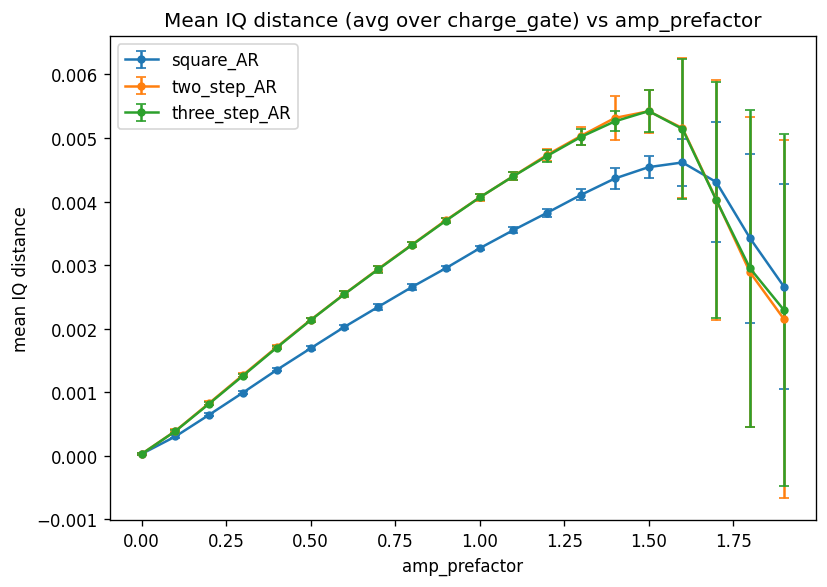

In [4]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

for label, result_ds in datasets.items():
    delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
               - result_ds['I_mean_set2'].sel(prepared_state=1))
    delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
               - result_ds['Q_mean_set2'].sel(prepared_state=1))
    distance = np.sqrt(delta_I**2 + delta_Q**2)

    mean_dist_vs_amp = distance.mean(dim='charge_gate')
    std_dist_vs_amp = distance.std(dim='charge_gate')
    ax.errorbar(mean_dist_vs_amp.coords['amp_prefactor'].values, mean_dist_vs_amp.values,
                yerr=std_dist_vs_amp.values, marker='o', markersize=4, capsize=3, label=label)

ax.set_xlabel('amp_prefactor')
ax.set_ylabel('mean IQ distance')
ax.set_title('Mean IQ distance (avg over charge_gate) vs amp_prefactor')
ax.legend()
fig.tight_layout()

fname = "cross_shape_mean_IQ_distance_vs_amp.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved cross_shape_mean_outlier_prob_state_0.png


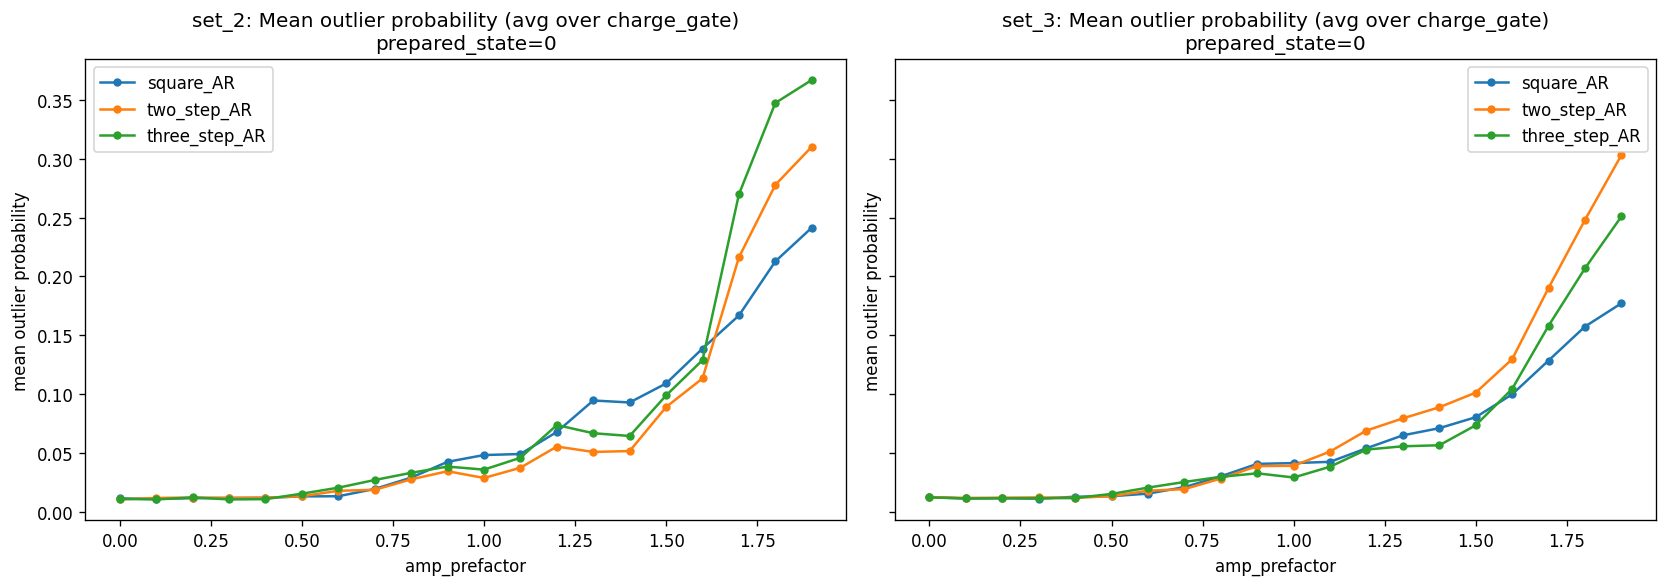

Saved cross_shape_mean_outlier_prob_state_1.png


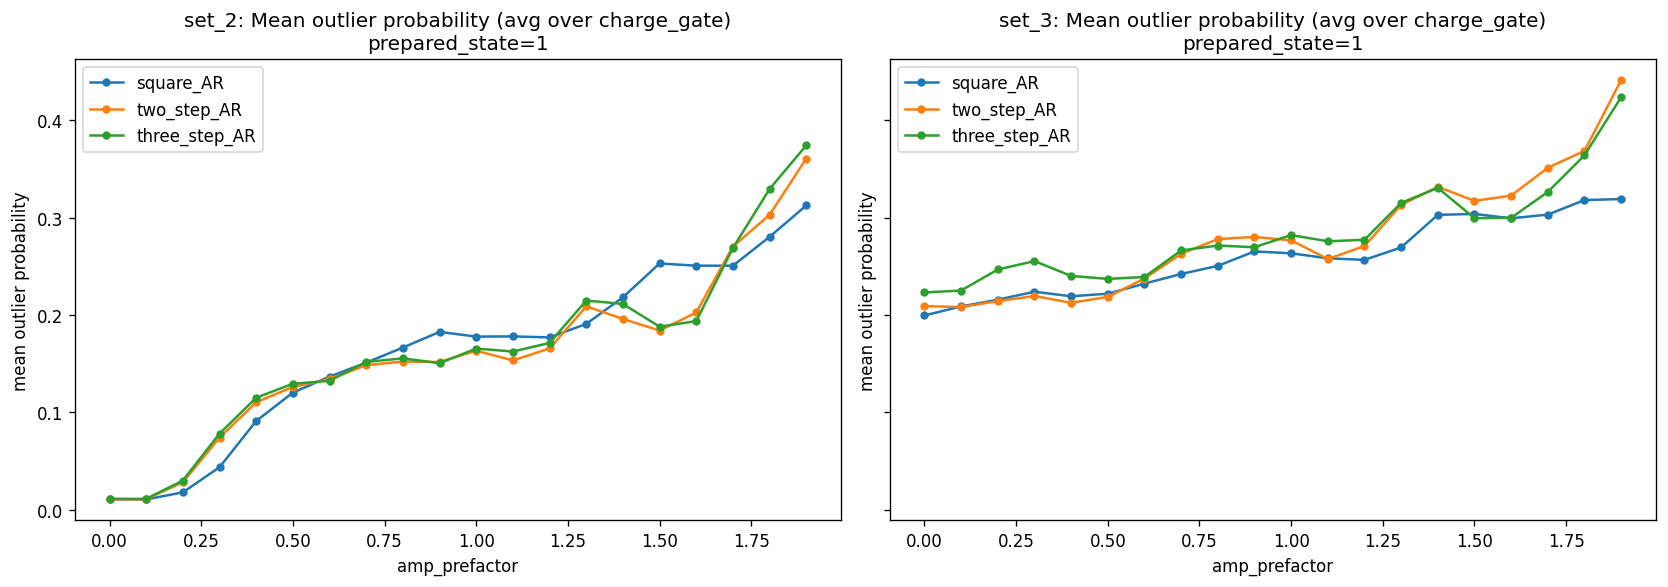

In [5]:
for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]
        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            data = result_ds[var_name].sel(prepared_state=state)
            mean_outlier = data.mean(dim='charge_gate')
            ax.plot(mean_outlier.coords['amp_prefactor'].values, mean_outlier.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('mean outlier probability')
        ax.set_title(f'{set_label}: Mean outlier probability (avg over charge_gate)\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_mean_outlier_prob_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_over_distance_state_0.png


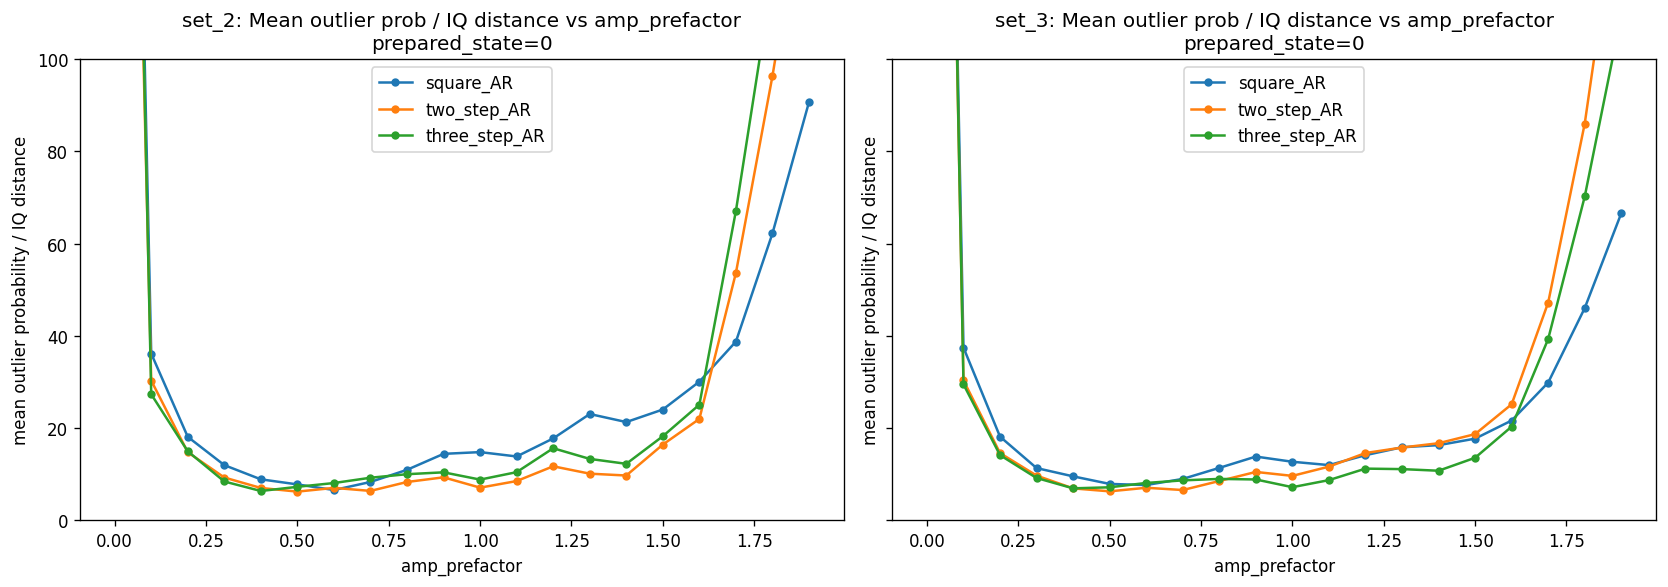

Saved cross_shape_outlier_over_distance_state_1.png


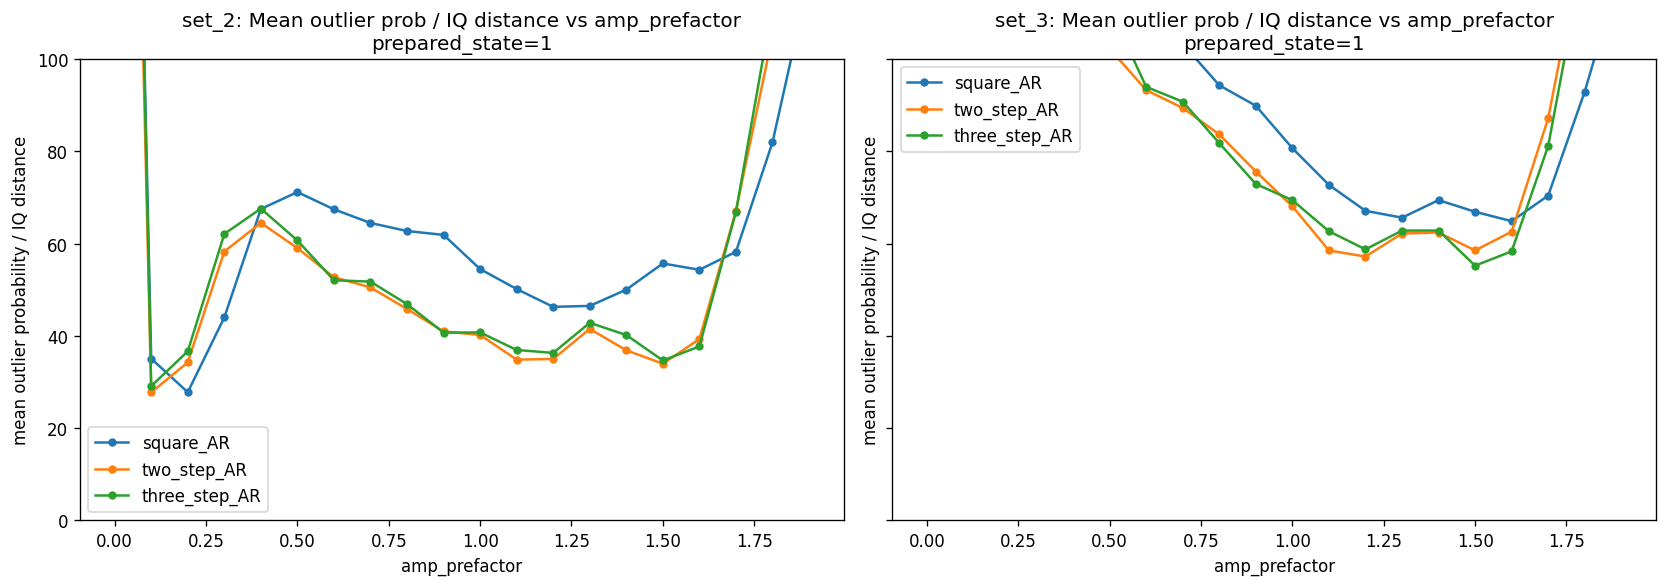

In [6]:
# Mean outlier probability / IQ distance, averaged along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            mean_outlier = result_ds[var_name].sel(prepared_state=state).mean(dim='charge_gate')
            ratio = mean_outlier / mean_dist
            ratio.plot.line(ax=ax, marker='o', markersize=4, linestyle='-',
                            color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_ylim(0, 100)
        # ax.set_yscale('log')
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('mean outlier probability / IQ distance')
        ax.set_title(f'{set_label}: Mean outlier prob / IQ distance vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_outlier_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_max_outlier_over_distance_state_0.png


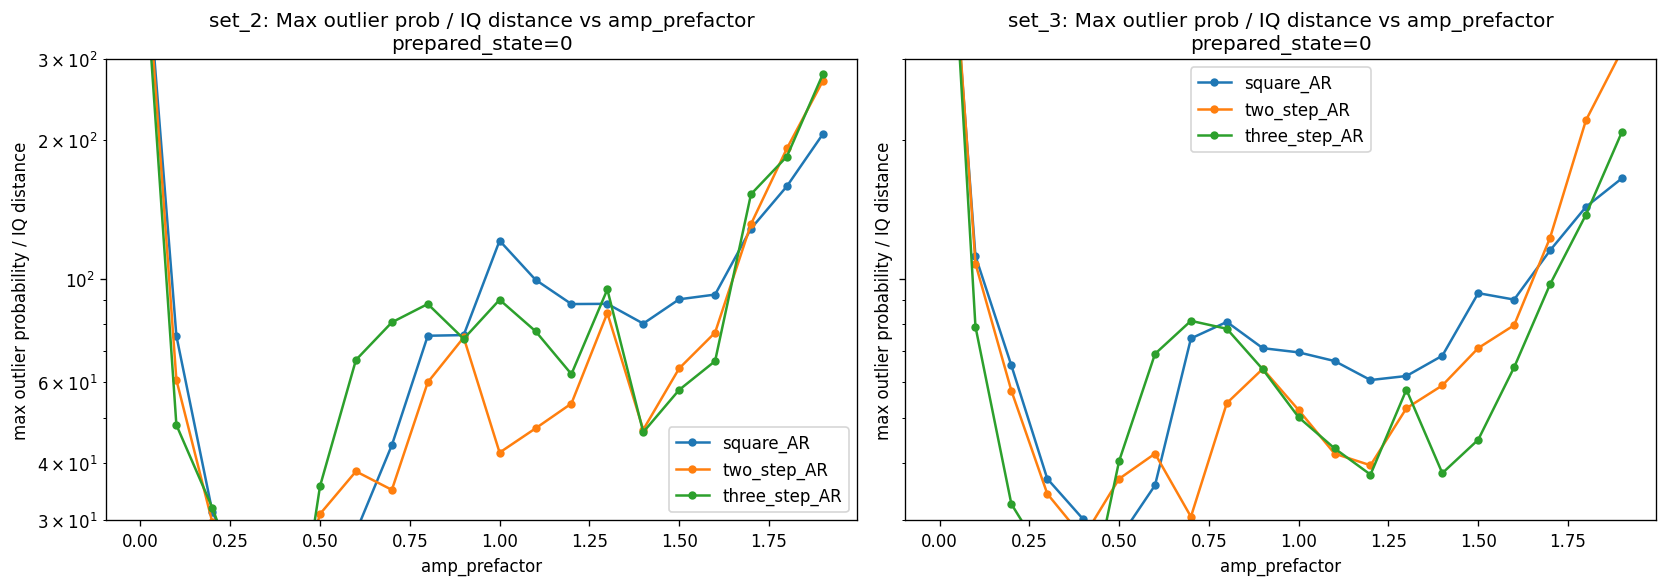

Saved cross_shape_max_outlier_over_distance_state_1.png


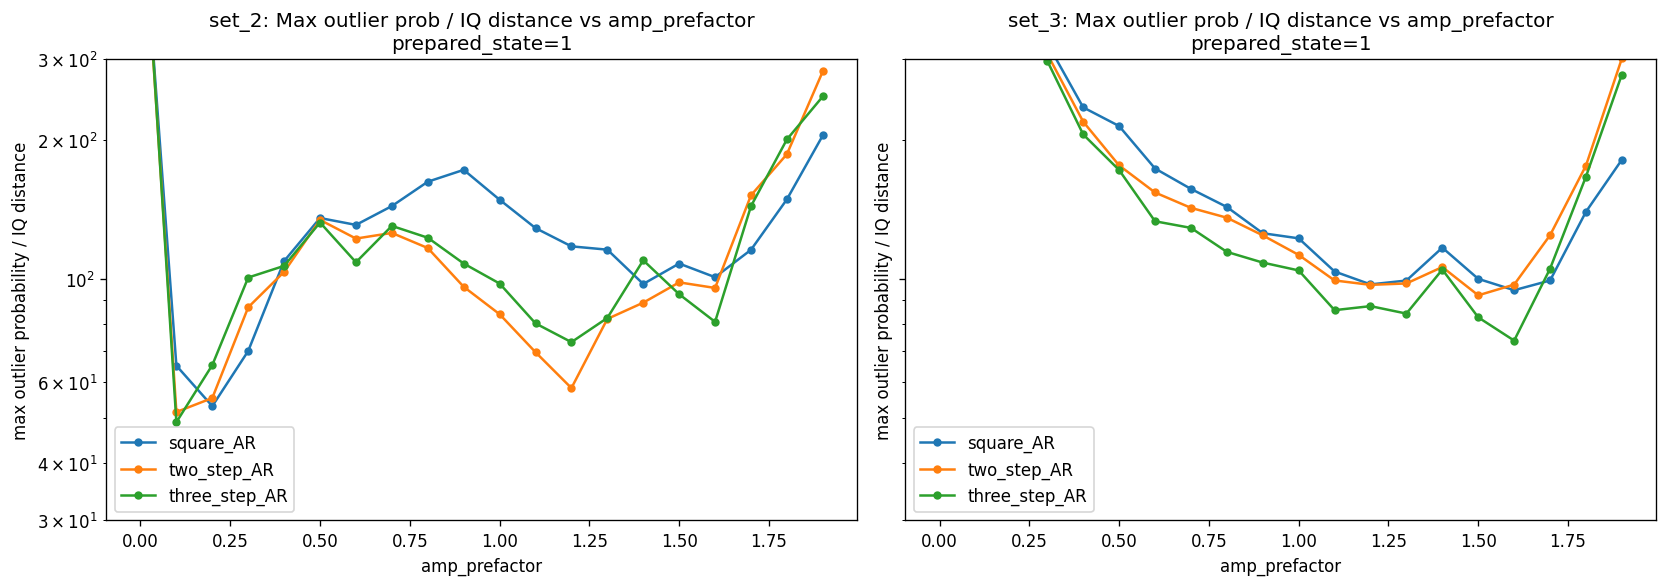

In [7]:
# Max outlier probability / IQ distance along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            max_outlier = result_ds[var_name].sel(prepared_state=state).max(dim='charge_gate')
            ratio = max_outlier / mean_dist
            ratio.plot.line(ax=ax, marker='o', markersize=4, linestyle='-',
                            color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_ylim(30, 300)
        ax.set_yscale('log')
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('max outlier probability / IQ distance')
        ax.set_title(f'{set_label}: Max outlier prob / IQ distance vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_max_outlier_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_min_outlier_over_distance_state_0.png


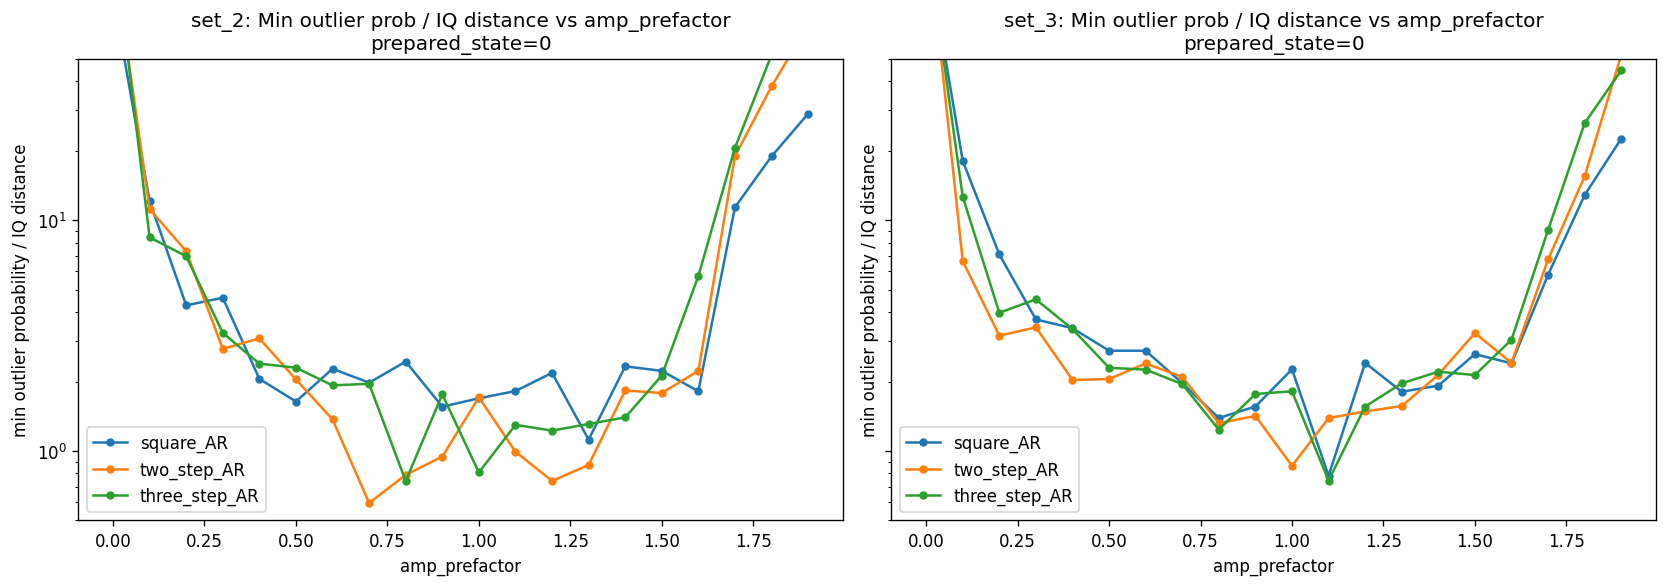

Saved cross_shape_min_outlier_over_distance_state_1.png


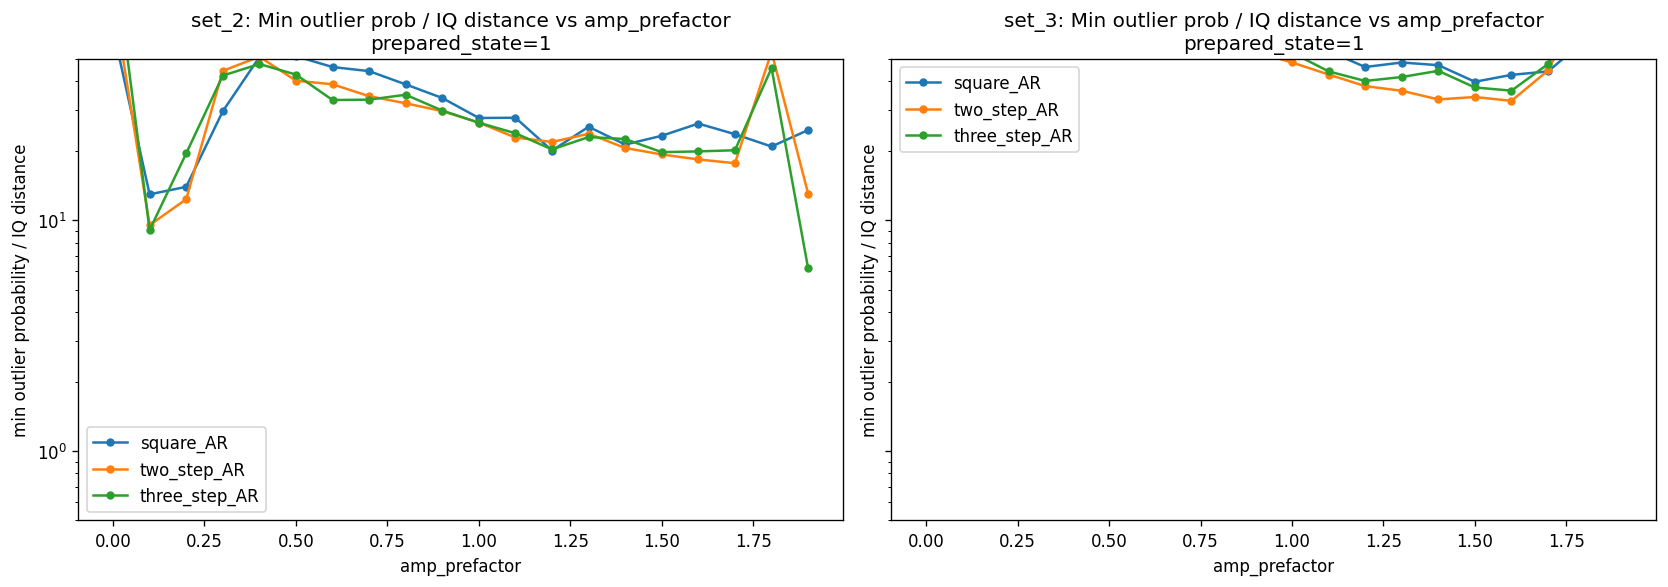

In [8]:
# Min outlier probability / IQ distance along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            min_outlier = result_ds[var_name].sel(prepared_state=state).min(dim='charge_gate')
            ratio = min_outlier / mean_dist
            ratio.plot.line(ax=ax, marker='o', markersize=4, linestyle='-',
                            color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_ylim(0.5, 50)
        ax.set_yscale('log')
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('min outlier probability / IQ distance')
        ax.set_title(f'{set_label}: Min outlier prob / IQ distance vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_min_outlier_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_vs_charge_gate_amp0_state_0.png


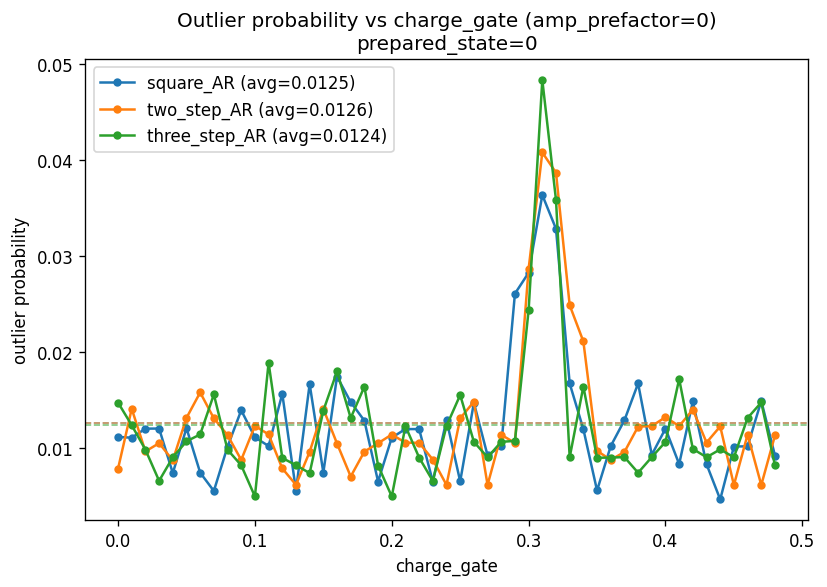

Saved cross_shape_outlier_vs_charge_gate_amp0_state_1.png


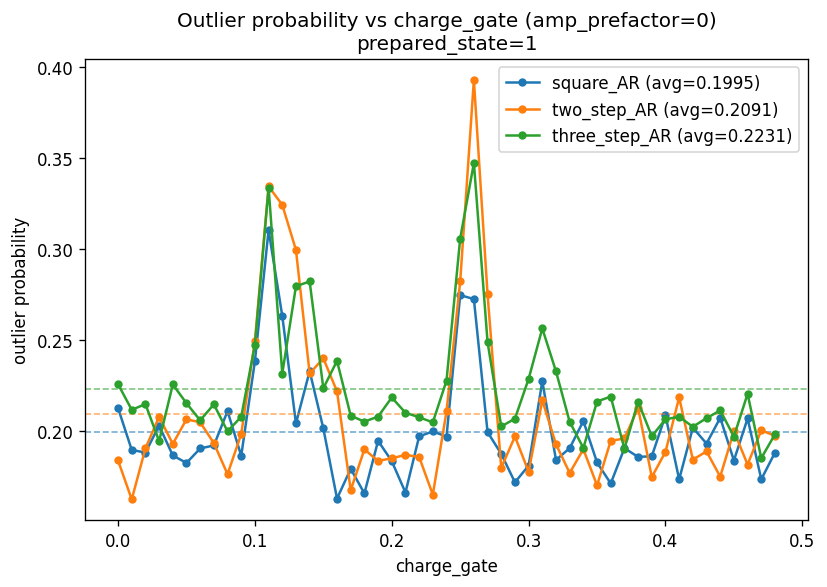

In [9]:
# Outlier probability vs charge_gate at amp_prefactor=0, one figure per prepared_state

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        outlier = result_ds['outlier_probability_set3'].sel(prepared_state=state, amp_prefactor=0, method='nearest')
        mean_val = float(outlier.mean())
        outlier.plot.line(ax=ax, x='charge_gate', marker='o', markersize=4,
                         color=color, label=f'{label} (avg={mean_val:.4f})')
        ax.axhline(mean_val, color=color, linestyle='--', linewidth=1, alpha=0.6)

    ax.set_xlabel('charge_gate')
    ax.set_ylabel('outlier probability')
    ax.set_title(f'Outlier probability vs charge_gate (amp_prefactor=0)\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"cross_shape_outlier_vs_charge_gate_amp0_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_delta_vs_amp_state_0.png


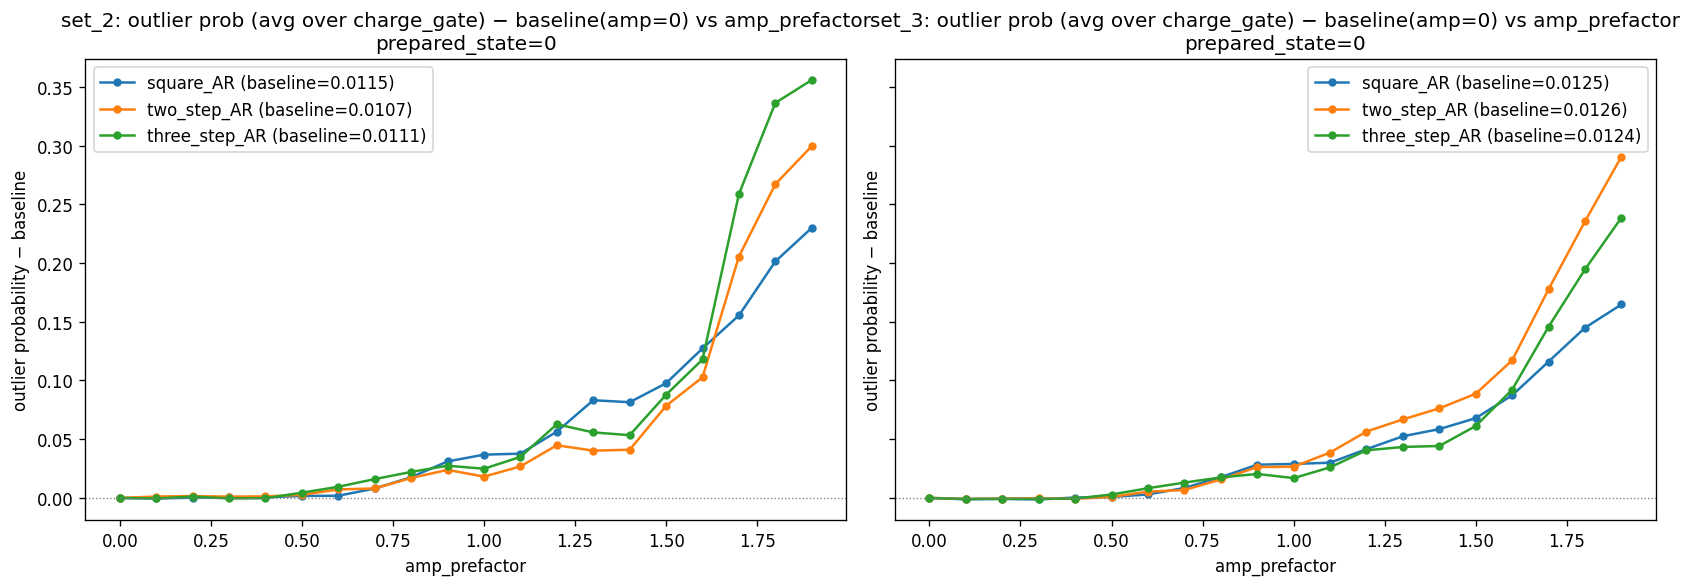

Saved cross_shape_outlier_delta_vs_amp_state_1.png


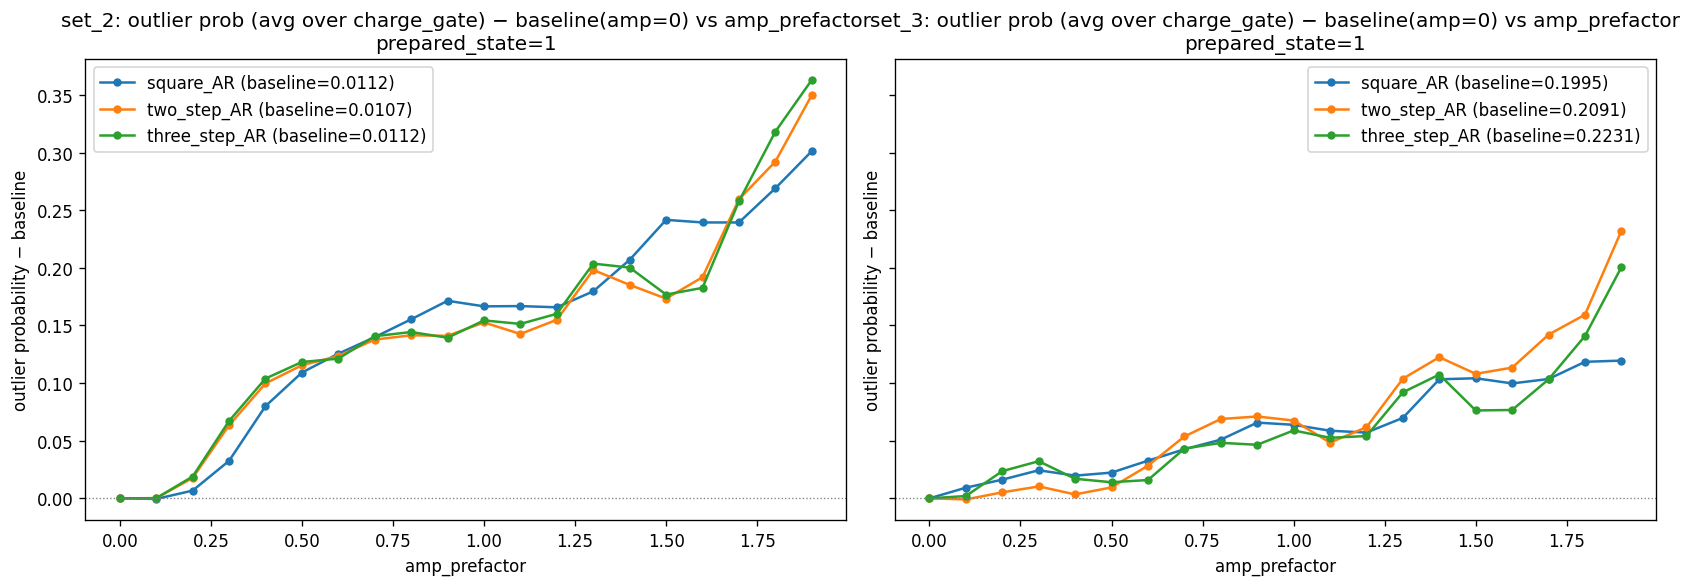

In [10]:
# set_2 / set_3 outlier probability (avg over charge_gate) minus baseline at amp_prefactor=0, vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            outlier = result_ds[var_name].sel(prepared_state=state)
            baseline = float(outlier.sel(amp_prefactor=0, method='nearest').mean(dim='charge_gate'))
            mean_outlier_vs_amp = outlier.mean(dim='charge_gate')
            delta = mean_outlier_vs_amp - baseline
            ax.plot(delta.coords['amp_prefactor'].values, delta.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=f'{label} (baseline={baseline:.4f})')

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('outlier probability − baseline')
        ax.set_title(f'{set_label}: outlier prob (avg over charge_gate) − baseline(amp=0) vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_outlier_delta_vs_amp_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_mean_delta_over_distance_state_0.png


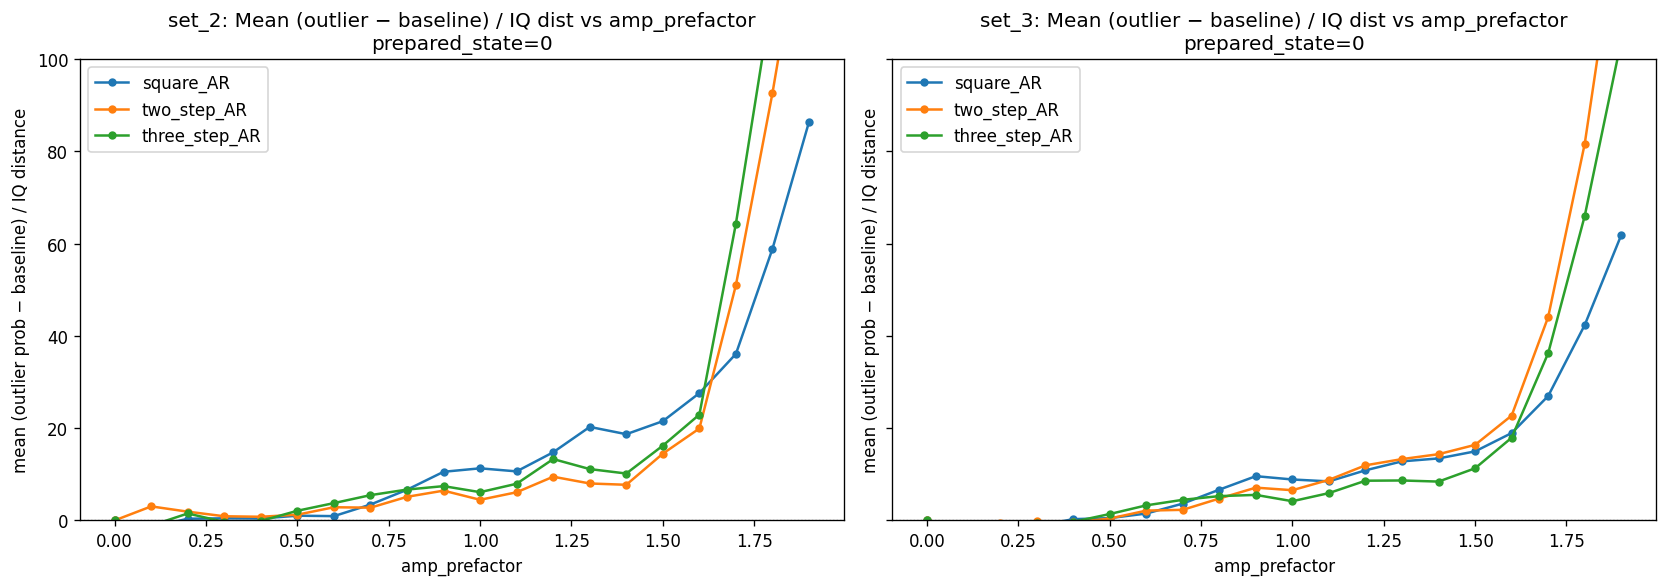

Saved cross_shape_mean_delta_over_distance_state_1.png


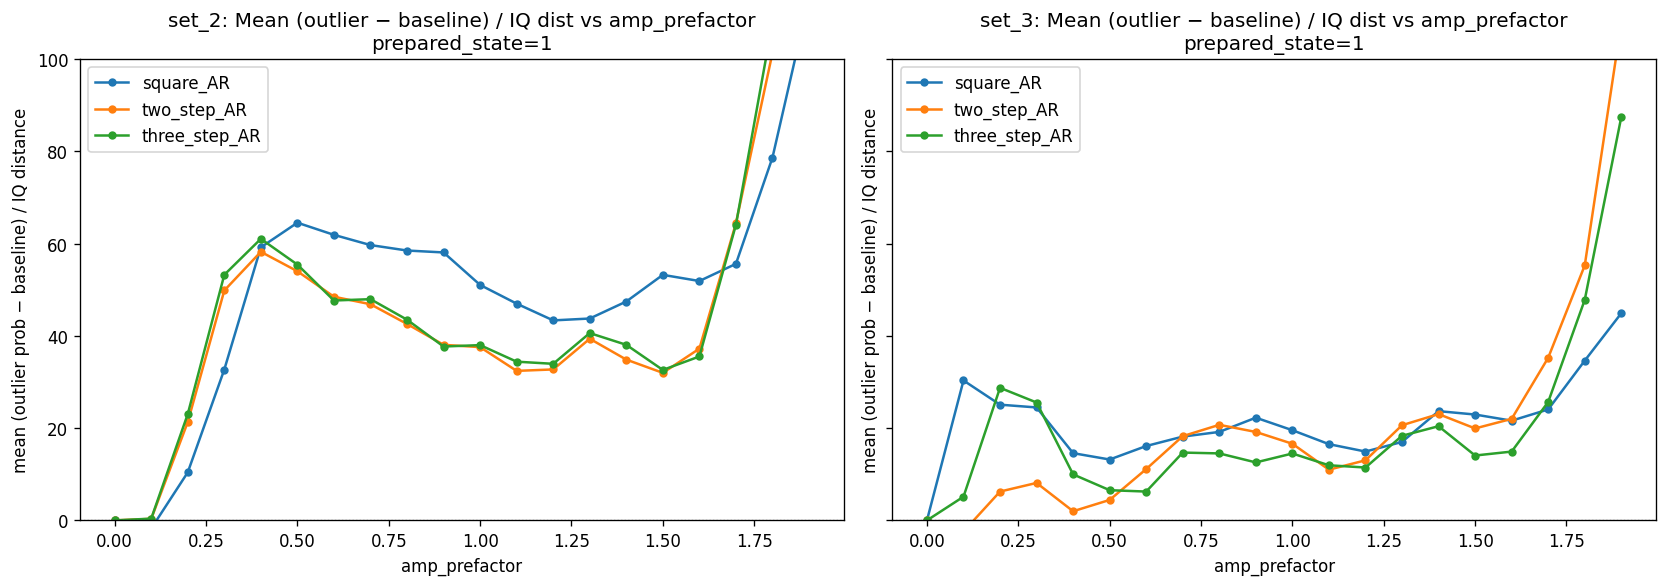

In [11]:
# Mean (outlier prob − baseline) / IQ distance, averaged along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            outlier = result_ds[var_name].sel(prepared_state=state)
            baseline = float(outlier.sel(amp_prefactor=0, method='nearest').mean(dim='charge_gate'))
            delta = outlier - baseline
            mean_delta = delta.mean(dim='charge_gate')
            ratio = mean_delta / mean_dist
            ax.plot(ratio.coords['amp_prefactor'].values, ratio.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_ylim(0, 100)
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('mean (outlier prob − baseline) / IQ distance')
        ax.set_title(f'{set_label}: Mean (outlier − baseline) / IQ dist vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_mean_delta_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_max_delta_over_distance_state_0.png


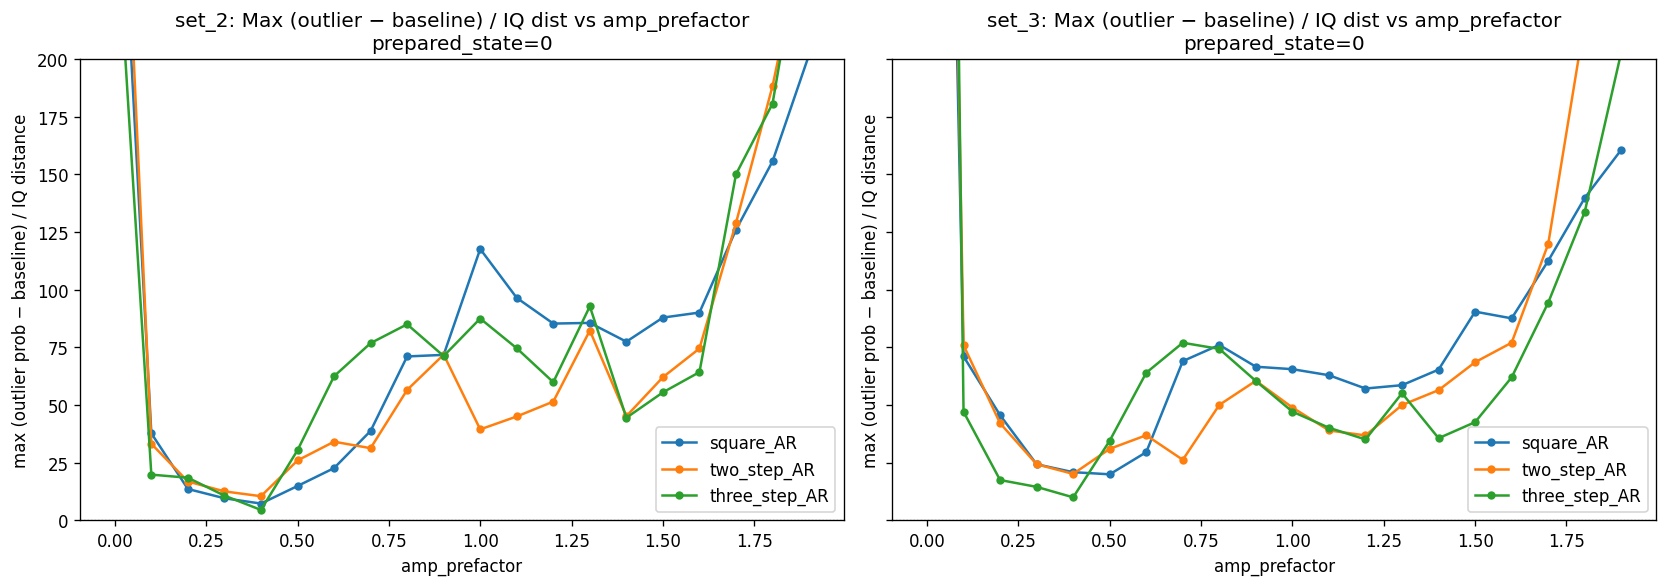

Saved cross_shape_max_delta_over_distance_state_1.png


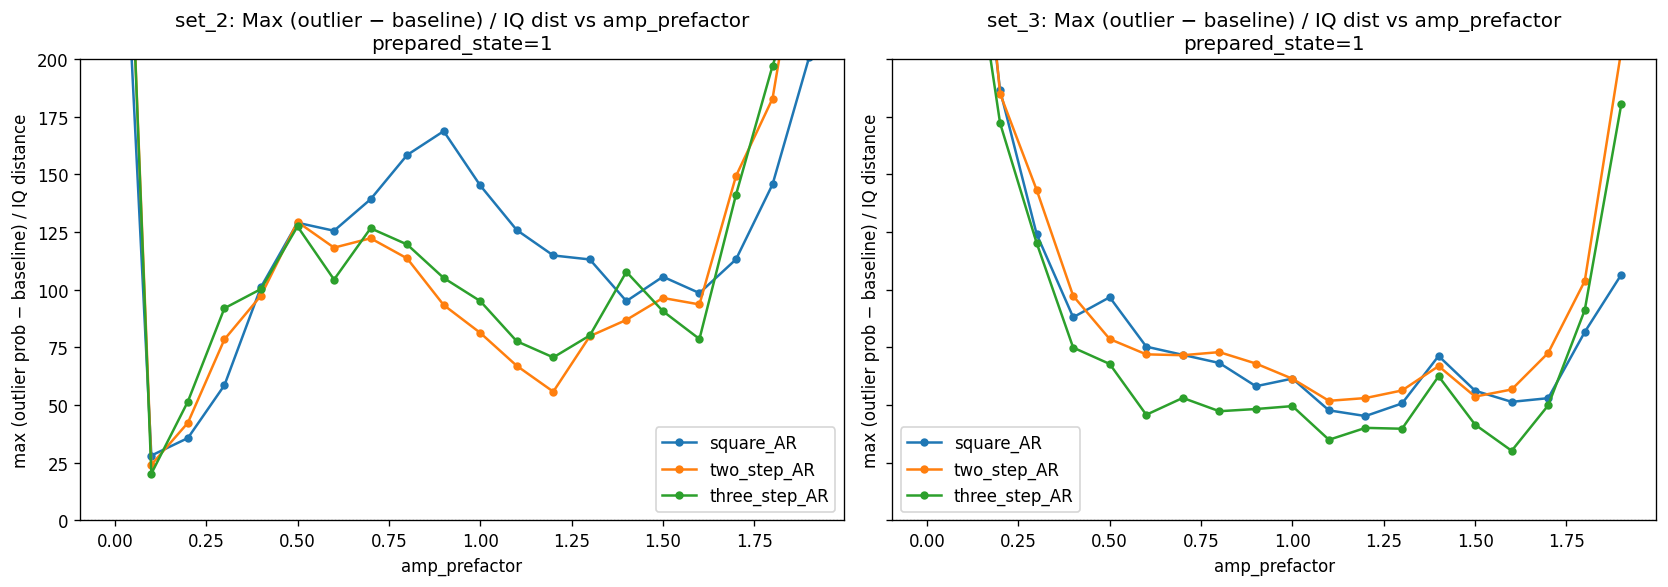

In [12]:
# Max (outlier prob − baseline) / IQ distance along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            outlier = result_ds[var_name].sel(prepared_state=state)
            baseline = float(outlier.sel(amp_prefactor=0, method='nearest').mean(dim='charge_gate'))
            delta = outlier - baseline
            max_delta = delta.max(dim='charge_gate')
            ratio = max_delta / mean_dist
            ax.plot(ratio.coords['amp_prefactor'].values, ratio.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_ylim(0, 200)
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('max (outlier prob − baseline) / IQ distance')
        ax.set_title(f'{set_label}: Max (outlier − baseline) / IQ dist vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_max_delta_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_min_delta_over_distance_state_0.png


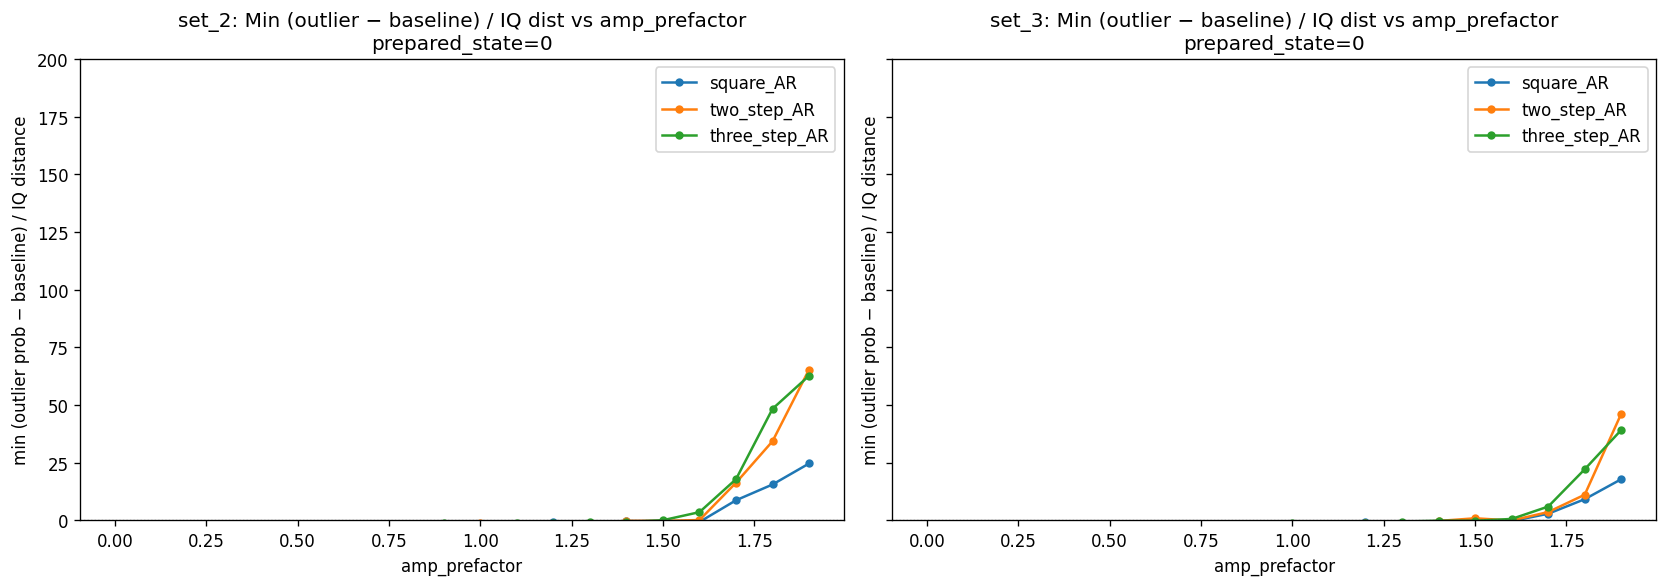

Saved cross_shape_min_delta_over_distance_state_1.png


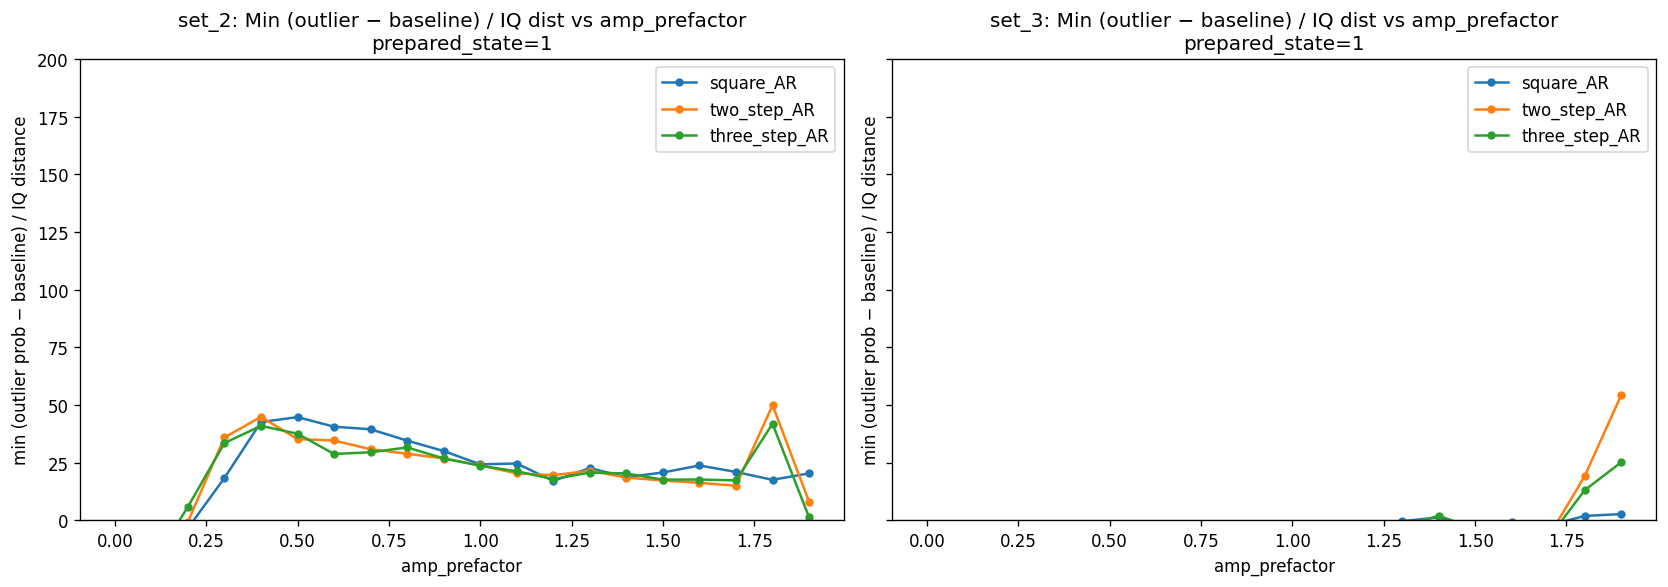

In [13]:
# Min (outlier prob − baseline) / IQ distance along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            outlier = result_ds[var_name].sel(prepared_state=state)
            baseline = float(outlier.sel(amp_prefactor=0, method='nearest').mean(dim='charge_gate'))
            delta = outlier - baseline
            min_delta = delta.min(dim='charge_gate')
            ratio = min_delta / mean_dist
            ax.plot(ratio.coords['amp_prefactor'].values, ratio.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_ylim(0, 200)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('min (outlier prob − baseline) / IQ distance')
        ax.set_title(f'{set_label}: Min (outlier − baseline) / IQ dist vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend()

    fig.tight_layout()

    fname = f"cross_shape_min_delta_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_maxmin_outlier_over_distance_state_0.png


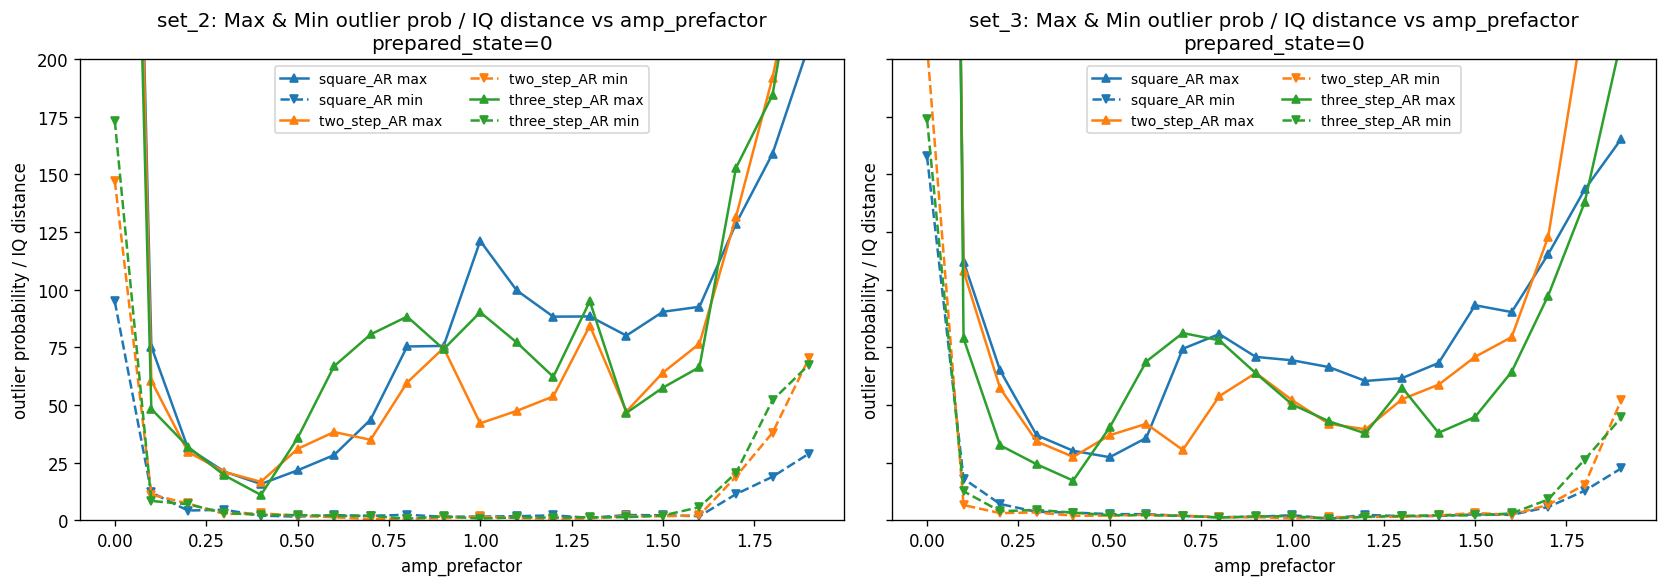

Saved cross_shape_maxmin_outlier_over_distance_state_1.png


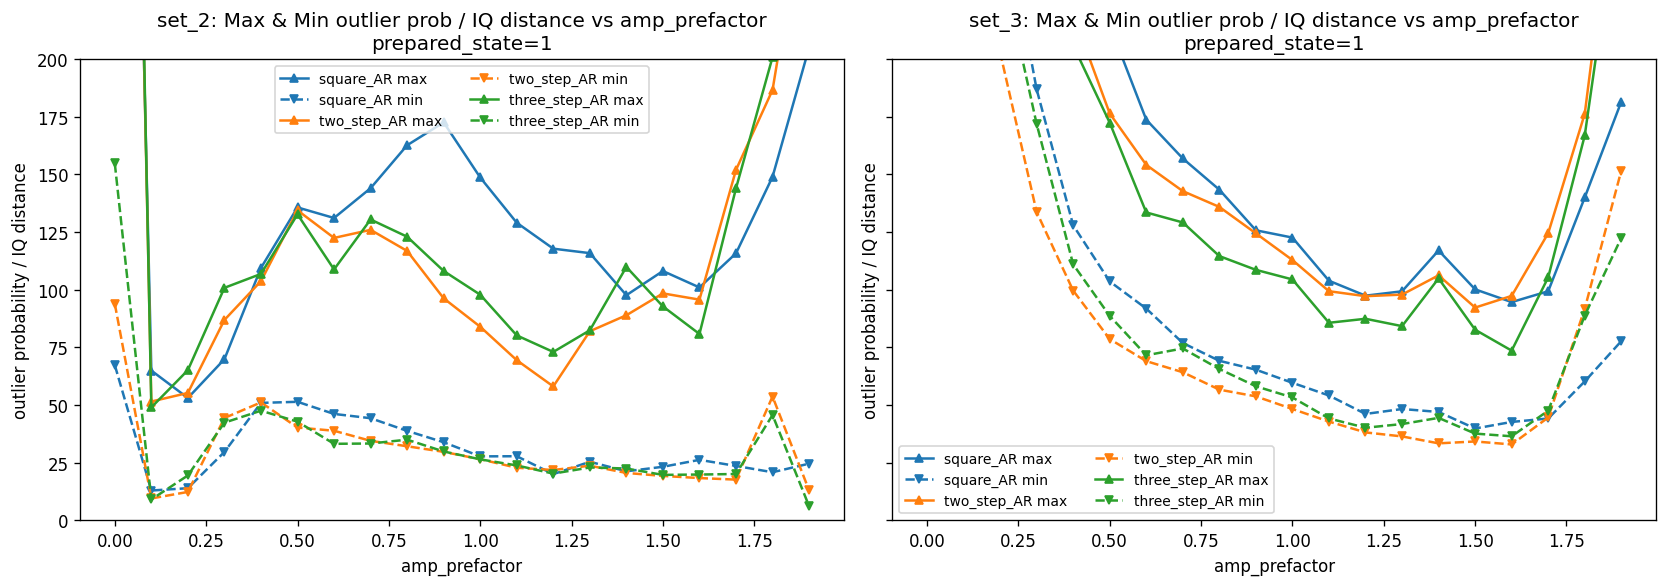

In [14]:
# Max & Min outlier probability / IQ distance along charge_gate vs amp_prefactor (combined)

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ax in [('outlier_probability_set2', 'set_2', ax_set2),
                                         ('outlier_probability_set3', 'set_3', ax_set3)]:
            data = result_ds[var_name].sel(prepared_state=state)
            max_outlier = data.max(dim='charge_gate')
            min_outlier = data.min(dim='charge_gate')
            ratio_max = max_outlier / mean_dist
            ratio_min = min_outlier / mean_dist
            amp = ratio_max.coords['amp_prefactor'].values
            ax.plot(amp, ratio_max.values, marker='^', markersize=5, linestyle='-',
                    color=color, label=f'{label} max')
            ax.plot(amp, ratio_min.values, marker='v', markersize=5, linestyle='--',
                    color=color, label=f'{label} min')

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        # ax.set_yscale('log')
        ax.set_ylim(0,200)
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('outlier probability / IQ distance')
        ax.set_title(f'{set_label}: Max & Min outlier prob / IQ distance vs amp_prefactor\n'
                     f'prepared_state={int(state)}')
        ax.legend(fontsize='small', ncol=2)

    fig.tight_layout()

    fname = f"cross_shape_maxmin_outlier_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_pooled_outlier_prob_state_0.png


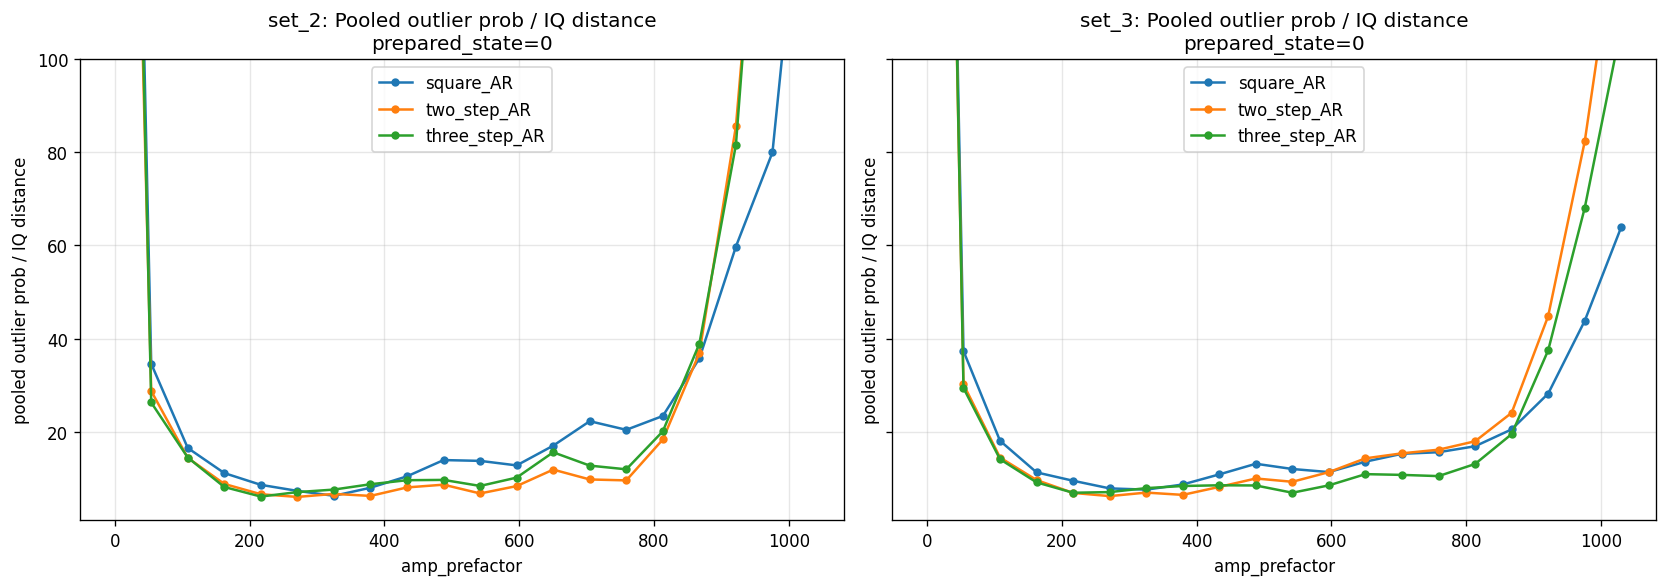

Saved cross_shape_pooled_outlier_prob_state_1.png


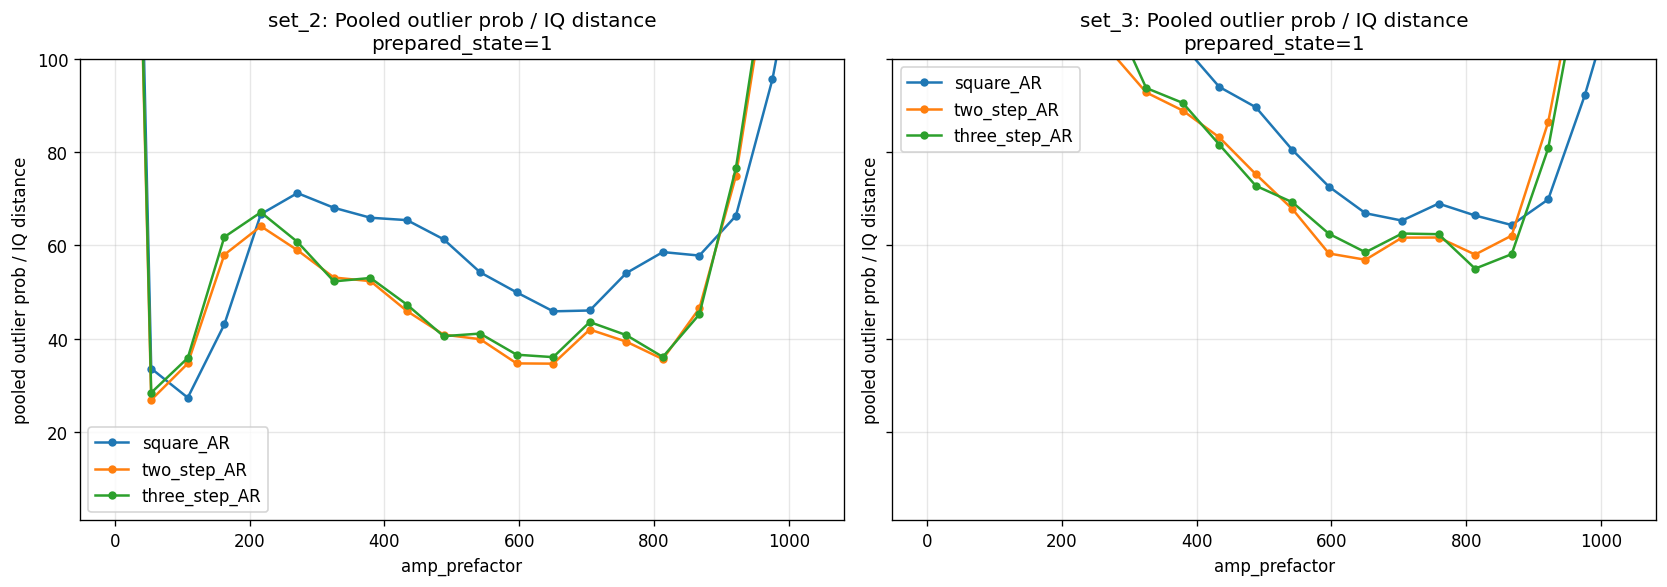

In [15]:
# Pooled outlier probability / IQ distance vs amp_prefactor

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]

        # IQ distance
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')
        photon_number = ratio.coords['amp_prefactor'].values * photon_convert_factor
        for var_name, set_label, ax in [
            ('pooled_outlier_probability_set2', 'set_2', ax_set2),
            ('pooled_outlier_probability_set3', 'set_3', ax_set3),
        ]:
            data = result_ds[var_name].sel(prepared_state=state)
            ratio = data / mean_dist
            ax.plot(photon_number, ratio.values,
                    marker='o', markersize=4, linestyle='-',
                    color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_xlabel('amp_prefactor')
        ax.set_ylabel('pooled outlier prob / IQ distance')
        ax.set_title(f'{set_label}: Pooled outlier prob / IQ distance\n'
                     f'prepared_state={int(state)}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        # ax.set_yscale('log')
        ax.set_ylim(1e0, 100)

    fig.tight_layout()

    fname = f"cross_shape_pooled_outlier_prob_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_pooled_outlier_vs_overlap_error_state_0.png


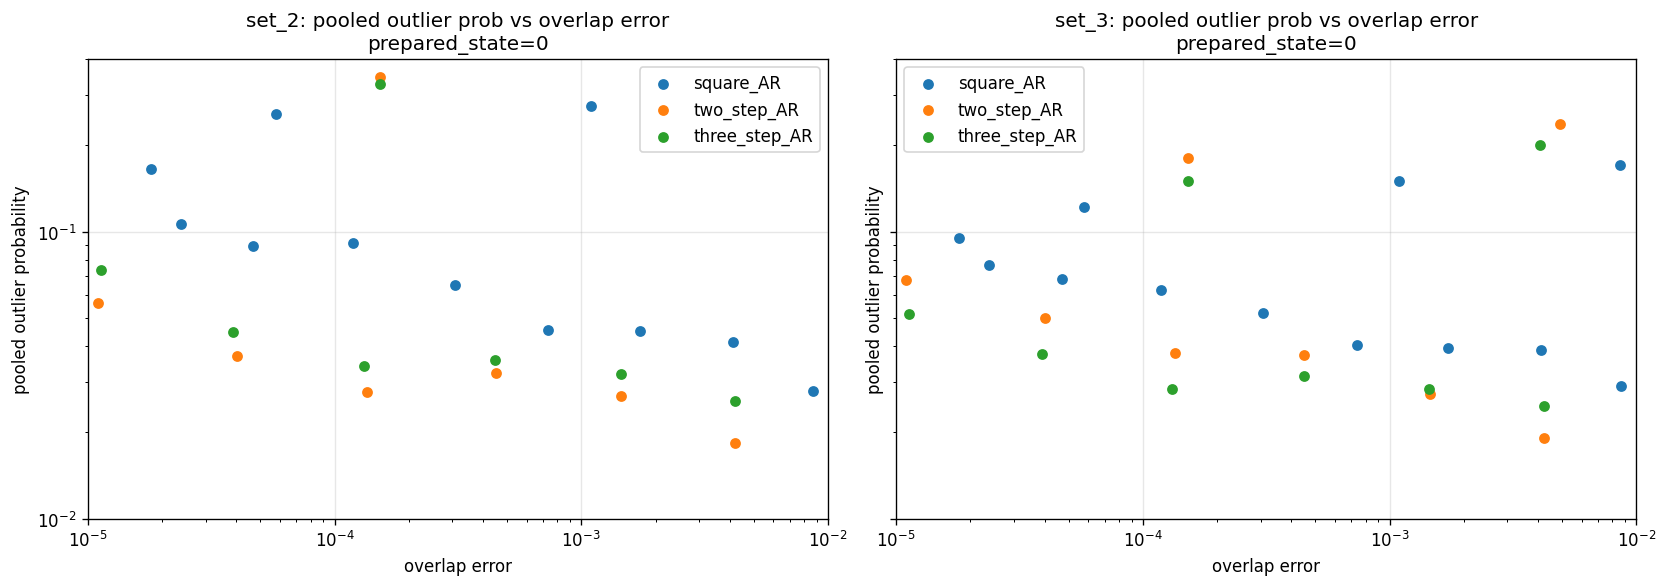

Saved cross_shape_pooled_outlier_vs_overlap_error_state_1.png


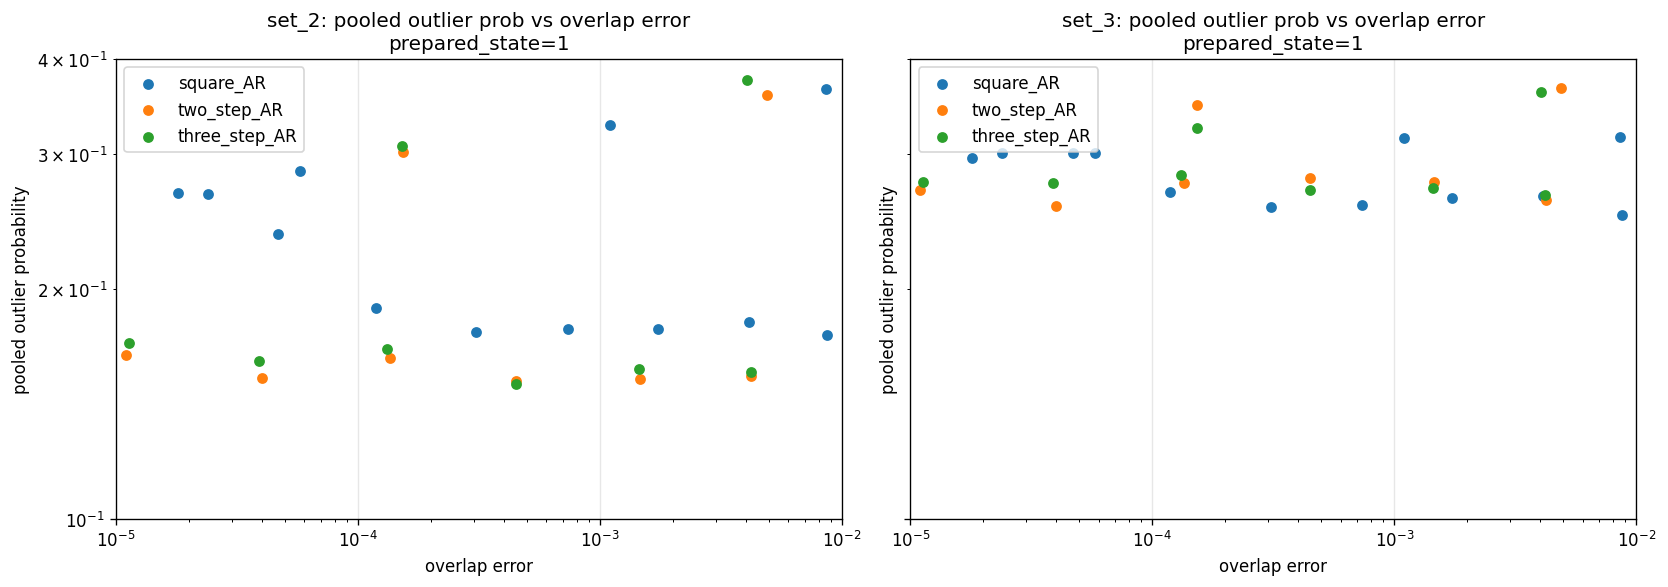

In [16]:
# Pooled outlier probability vs readout overlap error
# eps_o = 0.5 * (1 - erf(SNR / sqrt(8))),  SNR = IQ separation / sigma
# sigma = global 'std' from each dataset's attributes; one dot per photon number; one color per pulse shape.
from scipy.special import erf

window_xlim = [(0.00001, 0.01), (0.00001, 0.01)]  # state
window_ylim = [(0.01, 0.4), (0.1, 0.4)]  # state


for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]
        sigma = result_ds.attrs['std']  # scalar Gaussian width from attributes

        # IQ separation (signal): |blob(state0) - blob(state1)|, averaged over charge_gate
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        iq_sep = np.sqrt(delta_I**2 + delta_Q**2).mean(dim='charge_gate')  # (amp_prefactor,)

        snr = iq_sep.values / sigma
        overlap_error = 0.5 * (1.0 - erf(snr / np.sqrt(8.0)))  # (amp_prefactor,)

        for var_name, set_label, ax in [
            ('pooled_outlier_probability_set2', 'set_2', ax_set2),
            ('pooled_outlier_probability_set3', 'set_3', ax_set3),
        ]:
            y = result_ds[var_name].sel(prepared_state=state)
            ax.scatter(overlap_error, y.values, s=30, color=color, label=label)

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_xlim(window_xlim[state])
        ax.set_xscale('log')
        ax.set_ylim(window_ylim[state])
        ax.set_yscale('log')

        ax.set_xlabel('overlap error')
        ax.set_ylabel('pooled outlier probability')
        ax.set_title(f'{set_label}: pooled outlier prob vs overlap error\n'
                     f'prepared_state={int(state)}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.tight_layout()

    fname = f"cross_shape_pooled_outlier_vs_overlap_error_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_and_overlap_vs_photon_state_0.png


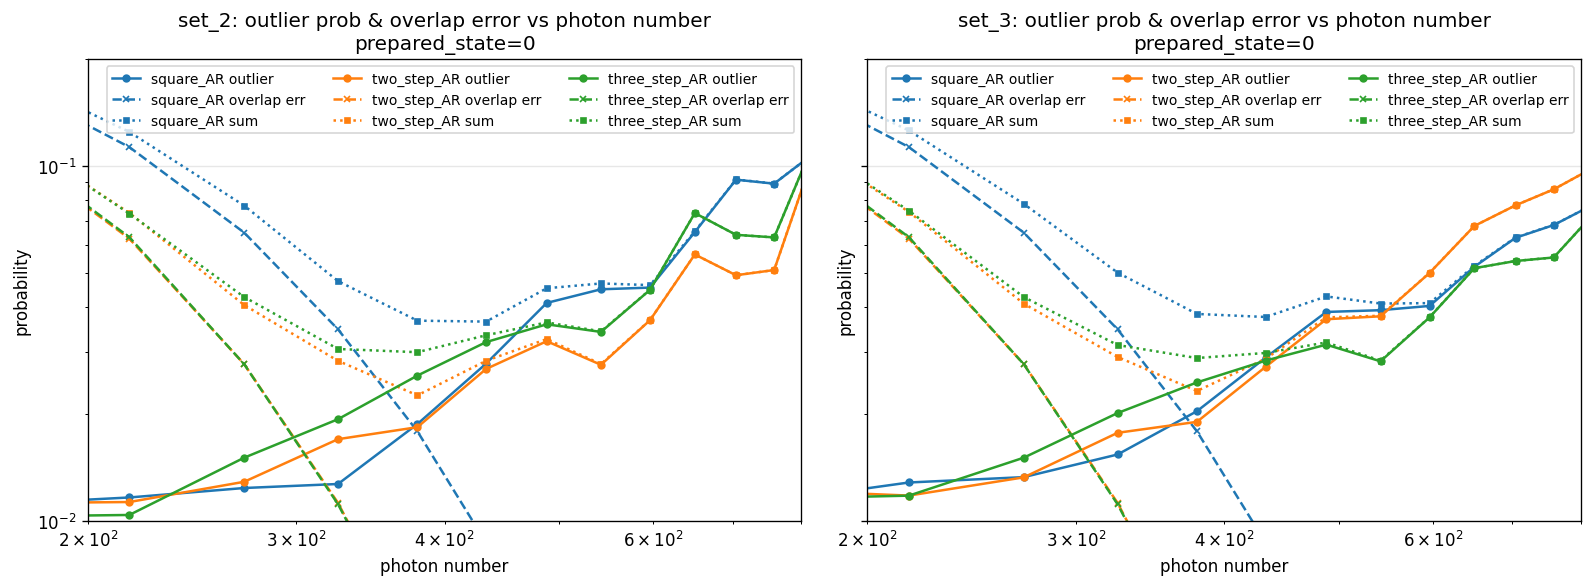

Saved cross_shape_outlier_and_overlap_vs_photon_state_1.png


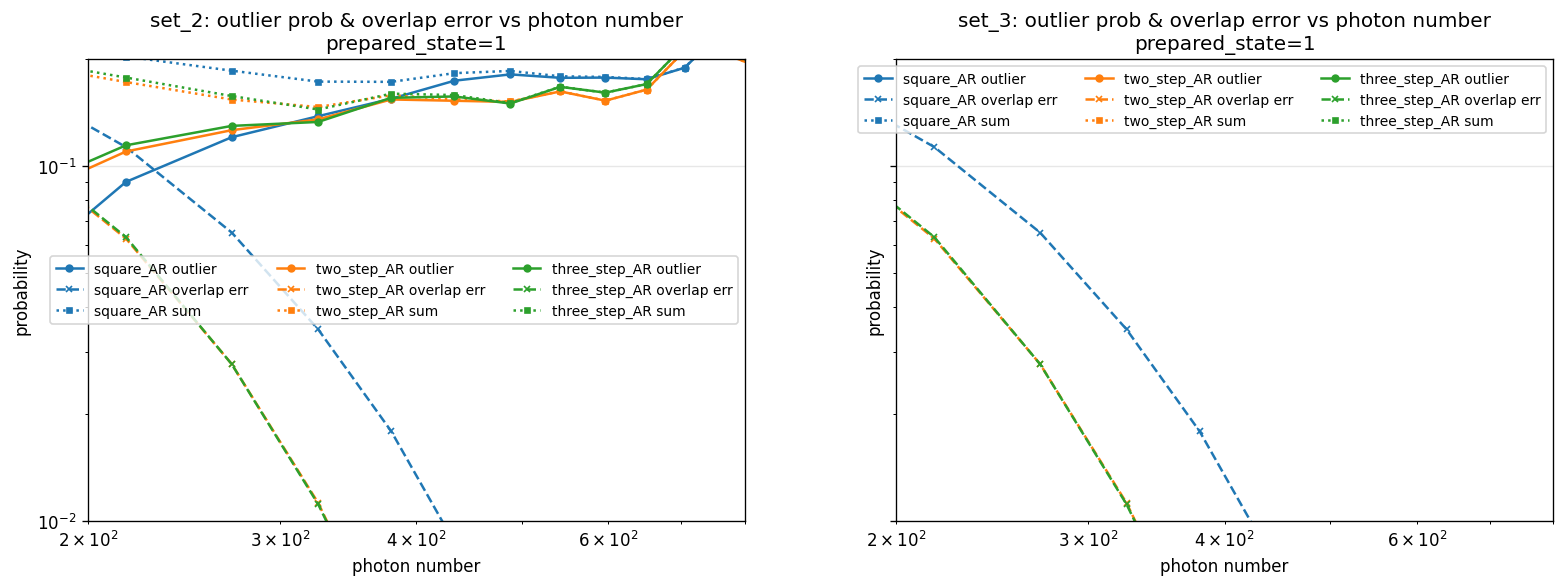

In [17]:
# Outlier probability & predicted overlap error vs photon number
# Each pulse shape -> 3 lines (same color): solid = measured pooled outlier probability,
# dashed = predicted overlap error  eps_o = 0.5 * (1 - erf(SNR / sqrt(8))), SNR = IQ separation / sigma,
# dotted = their sum (outlier + overlap error).
from scipy.special import erf

for state in prepared_states:
    fig, (ax_set2, ax_set3) = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharey=True)

    for label, result_ds in datasets.items():
        color = shape_colors[label]
        sigma = result_ds.attrs['std']  # scalar Gaussian width from attributes

        photon_number = result_ds.coords['amp_prefactor'].values * photon_convert_factor

        # IQ separation -> SNR -> predicted overlap error (set-independent)
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        iq_sep = np.sqrt(delta_I**2 + delta_Q**2).mean(dim='charge_gate').values  # (amp_prefactor,)
        snr = iq_sep / sigma
        overlap_error = 0.5 * (1.0 - erf(snr / np.sqrt(8.0)))

        for var_name, set_label, ax in [
            ('pooled_outlier_probability_set2', 'set_2', ax_set2),
            ('pooled_outlier_probability_set3', 'set_3', ax_set3),
        ]:
            outlier = result_ds[var_name].sel(prepared_state=state).values
            ax.plot(photon_number, outlier, marker='o', markersize=4, linestyle='-',
                    color=color, label=f'{label} outlier')
            ax.plot(photon_number, overlap_error, marker='x', markersize=4, linestyle='--',
                    color=color, label=f'{label} overlap err')
            ax.plot(photon_number, outlier + overlap_error, marker='s', markersize=3, linestyle=':',
                    color=color, label=f'{label} sum')

    for ax, set_label in [(ax_set2, 'set_2'), (ax_set3, 'set_3')]:
        ax.set_xlim(200, 800)
        ax.set_ylim(0.01, 0.2)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('photon number')
        ax.set_ylabel('probability')
        ax.set_title(f'{set_label}: outlier prob & overlap error vs photon number\n'
                     f'prepared_state={int(state)}')
        ax.legend(fontsize='small', ncol=3)
        ax.grid(True, alpha=0.3)

    fig.tight_layout()

    fname = f"cross_shape_outlier_and_overlap_vs_photon_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_pooled_outlier_diff_set3_set2_state_0.png


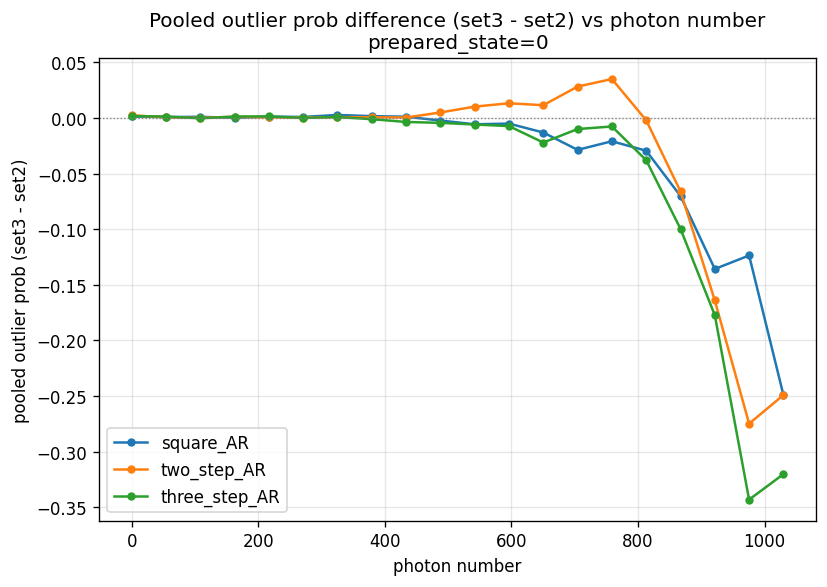

Saved cross_shape_pooled_outlier_diff_set3_set2_state_1.png


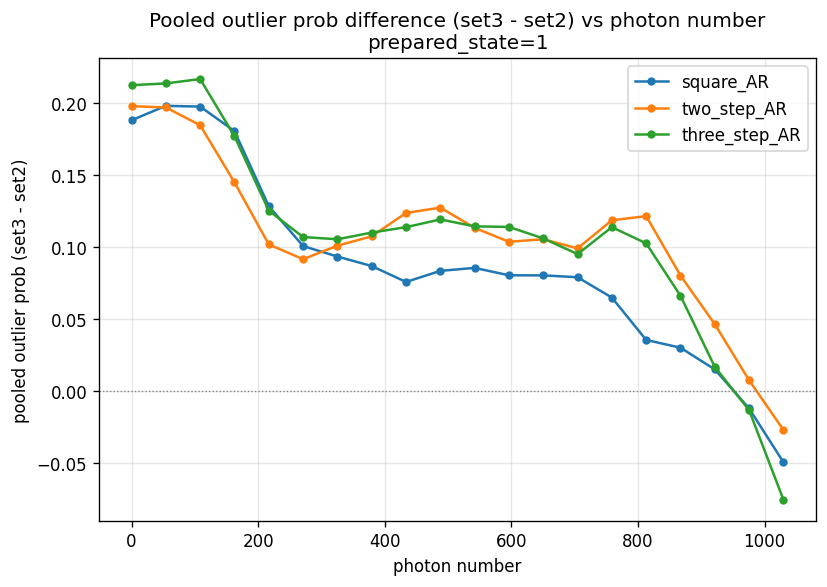

In [18]:
# Difference of pooled outlier probability (set3 - set2) vs photon number
# One figure per prepared_state, one line per pulse shape.

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for label, result_ds in datasets.items():
        color = shape_colors[label]
        photon_number = result_ds.coords['amp_prefactor'].values * photon_convert_factor

        set3 = result_ds['pooled_outlier_probability_set3'].sel(prepared_state=state).values
        set2 = result_ds['pooled_outlier_probability_set2'].sel(prepared_state=state).values
        diff = set3 - set2

        ax.plot(photon_number, diff, marker='o', markersize=4, linestyle='-',
                color=color, label=label)

    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('photon number')
    ax.set_ylabel('pooled outlier prob (set3 - set2)')
    ax.set_title(f'Pooled outlier prob difference (set3 - set2) vs photon number\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fname = f"cross_shape_pooled_outlier_diff_set3_set2_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

In [20]:
# Build pooled_outlier_ratio_data: xr.Dataset with dims (shape, prepared_state, photon_number)
# M2 = pooled_outlier_probability_set2 / mean_IQ_distance
# M3 = pooled_outlier_probability_set3 / mean_IQ_distance

shape_ds_list = []
for label, result_ds in datasets.items():
    delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
               - result_ds['I_mean_set2'].sel(prepared_state=1))
    delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
               - result_ds['Q_mean_set2'].sel(prepared_state=1))
    mean_dist = np.sqrt(delta_I**2 + delta_Q**2).mean(dim='charge_gate')  # (amp_prefactor,)

    photon_number = result_ds.coords['amp_prefactor'].values * photon_convert_factor

    per_state_M2, per_state_M3 = [], []
    for state in prepared_states:
        per_state_M2.append((result_ds['pooled_outlier_probability_set2'].sel(prepared_state=state) / mean_dist).values)
        per_state_M3.append((result_ds['pooled_outlier_probability_set3'].sel(prepared_state=state) / mean_dist).values)

    ds = xr.Dataset({
        'M2': xr.DataArray(np.array(per_state_M2),
                           dims=['prepared_state', 'photon_number'],
                           coords={'prepared_state': prepared_states, 'photon_number': photon_number}),
        'M3': xr.DataArray(np.array(per_state_M3),
                           dims=['prepared_state', 'photon_number'],
                           coords={'prepared_state': prepared_states, 'photon_number': photon_number}),
    }).expand_dims({'shape': [label]})
    shape_ds_list.append(ds)

pooled_outlier_ratio_data = xr.concat(shape_ds_list, dim='shape')
print(pooled_outlier_ratio_data)

save_path = os.path.join(output_folder, "pooled_outlier_ratio_data.h5")
pooled_outlier_ratio_data.to_netcdf(save_path, engine='h5netcdf')
print(f"Saved pooled_outlier_ratio_data to {save_path}")


<xarray.Dataset> Size: 2kB
Dimensions:         (shape: 3, prepared_state: 2, photon_number: 20)
Coordinates:
  * shape           (shape) object 24B 'square_AR' 'two_step_AR' 'three_step_AR'
  * prepared_state  (prepared_state) int32 8B 0 1
  * photon_number   (photon_number) float64 160B 0.0 54.2 ... 975.6 1.03e+03
Data variables:
    M2              (shape, prepared_state, photon_number) float64 960B 382.1...
    M3              (shape, prepared_state, photon_number) float64 960B 426.5...
Saved pooled_outlier_ratio_data to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\pooled_outlier_ratio_data.h5
